            # Week 4 - Driver Ratings Regression

            This notebook follows the Week 4 guide's driver-rating module using the motion dataset.

            ## Modeling note

            The original dataset does not provide real passenger star ratings, so `driver_rating_proxy`
            is used as the regression target. It is derived from trip severity and event counts to support
            the Week 4 analytics workflow.
            


In [2]:
            !pip install pandas numpy matplotlib seaborn scikit-learn
            


zsh:1: command not found: pip


In [4]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 5.3 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 78.1 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 6.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
            from pathlib import Path
            import pandas as pd
            import seaborn as sns
            import matplotlib.pyplot as plt
            from sklearn.model_selection import train_test_split
            from sklearn.linear_model import LinearRegression
            from sklearn.ensemble import RandomForestRegressor
            from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
            from sklearn.inspection import permutation_importance

            BASE_DIR = Path(r"/Users/ayet_dub/Documents/Codex/2026-05-11/files-mentioned-by-the-user-test")
            df = pd.read_csv(BASE_DIR / "data" / "telematics_trip_summary.csv")
            


In [6]:
            feature_cols = [
                "avg_acc_mag",
                "max_acc_mag",
                "std_acc_mag",
                "avg_gyro_mag",
                "max_gyro_mag",
                "avg_jerk_mag",
                "harsh_accel_events",
                "sharp_turn_events",
                "sudden_motion_events",
                "event_total",
                "samples",
            ]

            X = df[feature_cols]
            y = df["driver_rating_proxy"]

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
            


In [7]:
            linear_model = LinearRegression()
            linear_model.fit(X_train, y_train)
            linear_pred = linear_model.predict(X_test)

            rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
            rf_model.fit(X_train, y_train)
            rf_pred = rf_model.predict(X_test)

            def rmse(y_true, y_pred):
                return mean_squared_error(y_true, y_pred) ** 0.5

            print("Linear Regression")
            print("MAE:", mean_absolute_error(y_test, linear_pred))
            print("RMSE:", rmse(y_test, linear_pred))
            print("R2:", r2_score(y_test, linear_pred))
            print()
            print("Random Forest")
            print("MAE:", mean_absolute_error(y_test, rf_pred))
            print("RMSE:", rmse(y_test, rf_pred))
            print("R2:", r2_score(y_test, rf_pred))
            


Linear Regression
MAE: 0.4304519027015418
RMSE: 0.5190896448225194
R2: 0.5972857348626541

Random Forest
MAE: 0.48368115942028844
RMSE: 0.5583388121729881
R2: 0.5340836837520113


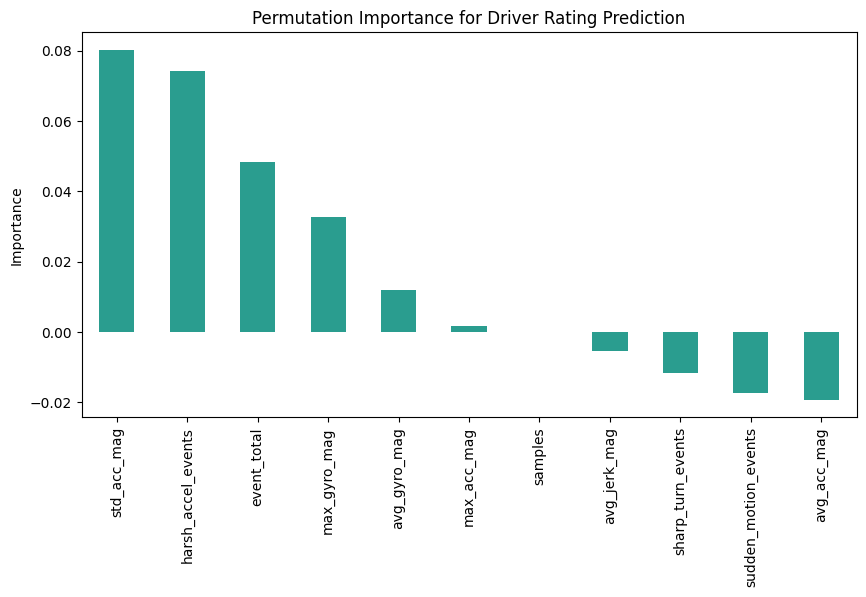

In [8]:
            importance = permutation_importance(
                rf_model,
                X_test,
                y_test,
                n_repeats=20,
                random_state=42,
            )

            importance_df = (
                pd.Series(importance.importances_mean, index=feature_cols)
                .sort_values(ascending=False)
            )

            importance_df.plot(kind="bar", figsize=(10, 5), color="#2a9d8f")
            plt.title("Permutation Importance for Driver Rating Prediction")
            plt.ylabel("Importance")
            plt.show()
            


## Interpretation

The telematics features are enough to provide a useful estimate of driver quality. In this notebook, the Linear Regression model performed better than the Random Forest model, with lower MAE and RMSE and a higher R2 score. The Linear Regression model achieved MAE = 0.4305, RMSE = 0.5191, and R2 = 0.5973, while the Random Forest model achieved MAE = 0.4837, RMSE = 0.5583, and R2 = 0.5341. These results show that the engineered telematics variables capture a meaningful amount of the variation in driver ratings.

The most influential features in the rating prediction were `std_acc_mag`, `harsh_accel_events`, `event_total`, and `max_gyro_mag`. This suggests that unstable acceleration, frequent harsh events, and stronger turning or motion intensity have the biggest effect on predicted driver ratings. In practical terms, drivers with more abrupt motion patterns and more risky driving events tend to receive lower predicted scores.

The regression output can feed the driver profile dashboard by adding a predicted rating score at the trip or driver level. This score can be combined with violation counts, event totals, and risk indicators to identify drivers who may need coaching, highlight high-risk driving patterns, and support monitoring over time. It can also help operations teams rank drivers by performance and prioritize follow-up actions more consistently.

            
